In [1]:
import pandas as p
import seaborn as sb
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

In [2]:
df_m = p.read_csv("share-of-women-who-are-smoking.csv")
df_m = df_m.sort_values(ascending=False, by="Share of female adults who smoke or use tobacco (age-standardized)")
df_m = df_m.rename(columns={"Share of female adults who smoke or use tobacco (age-standardized)": "Porcentaje de mujeres que fuman"})
df_h = p.read_csv("share-of-men-who-are-smoking.csv")
df_h = df_h.sort_values(ascending=False, by="Share of male adults who smoke or use tobacco (age-standardized)")
df_h = df_h.rename(columns={"Share of male adults who smoke or use tobacco (age-standardized)": "Distribución de hombres que fuman (%)"})

Deberíamos eliminar Corea del norte

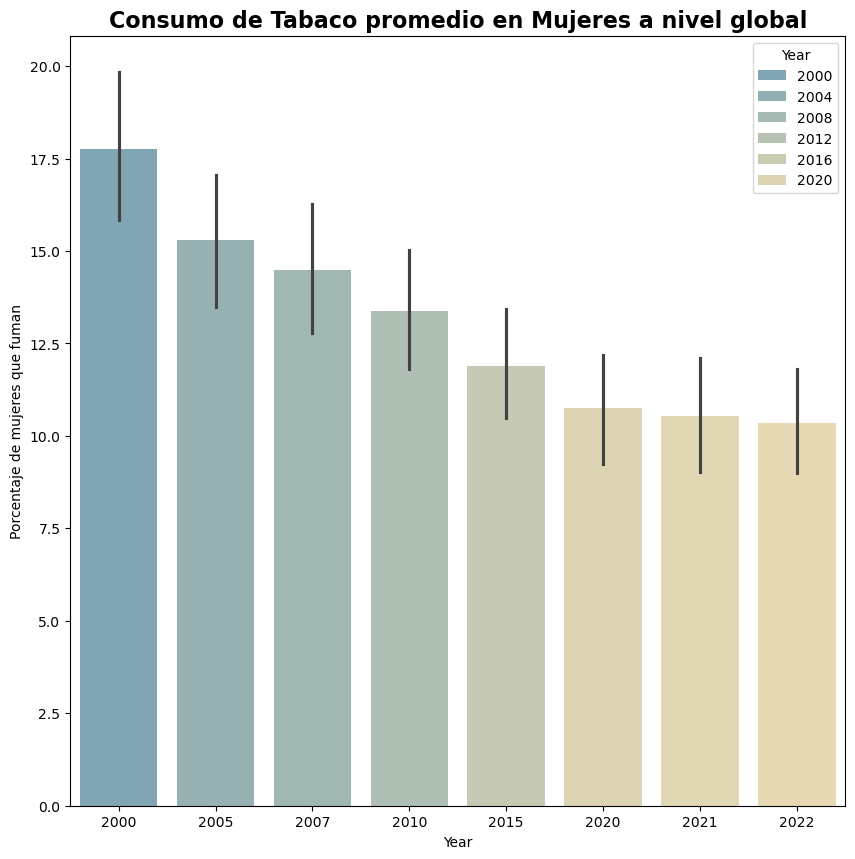

In [3]:
plt.figure(figsize=(10, 10))
sb.barplot(data=df_m, x="Year", y="Porcentaje de mujeres que fuman", hue="Year", palette="blend:#7AB,#EDA")
plt.title("Consumo de Tabaco promedio en Mujeres a nivel global", fontsize=16, fontweight='bold')
plt.show()

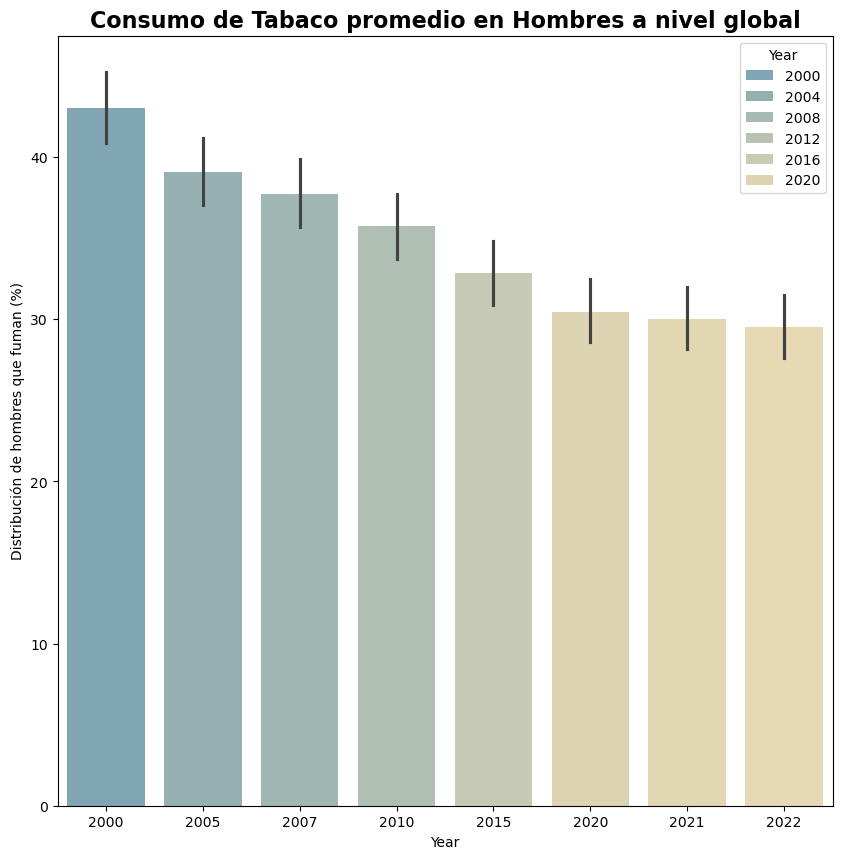

In [4]:
plt.figure(figsize=(10, 10))
sb.barplot(data=df_h, x="Year", y="Distribución de hombres que fuman (%)", hue="Year", palette="blend:#7AB,#EDA")
plt.title("Consumo de Tabaco promedio en Hombres a nivel global", fontsize=16, fontweight='bold')
plt.show()

In [5]:
df_prom_m = df_m.groupby("Entity")["Porcentaje de mujeres que fuman"].mean().reset_index()
df_prom_m = df_prom_m.sort_values("Porcentaje de mujeres que fuman", ascending=False).reset_index(drop=True)
df_prom_m

,Entity,Porcentaje de mujeres que fuman
0,Nauru,56.7875
1,Serbia,39.0750
2,Kiribati,37.2375
3,Bulgaria,37.1750
4,Greece,35.9875
...,...,...
171,Egypt,0.5750
172,Turkmenistan,0.5625
173,Oman,0.4875
174,Azerbaijan,0.1875


In [6]:
df_prom_h = df_h.groupby("Entity")["Distribución de hombres que fuman (%)"].mean().reset_index()
df_prom_h = df_prom_h.sort_values("Distribución de hombres que fuman (%)", ascending=False).reset_index(drop=True)
df_prom_h

,Entity,Distribución de hombres que fuman (%)
0,Myanmar,74.9750
1,East Timor,74.8750
2,Indonesia,68.5125
3,Kiribati,64.8375
4,Papua New Guinea,61.1750
...,...,...
171,Barbados,13.4250
172,Sao Tome and Principe,12.2875
173,Nigeria,10.7750
174,Ethiopia,9.8000


In [7]:
df_prom_h[df_prom_h["Entity"] == "Chile"]

,Entity,Distribución de hombres que fuman (%)
64,Chile,39.05


In [8]:
df_hombres_2022 = df_h[df_h["Year"] == 2022]
df_mujeres_2022 = df_m[df_m["Year"] == 2022]
df_final = p.merge(df_hombres_2022, df_mujeres_2022, on=["Entity", "Code", "Year"])

idx_max = df_final["Distribución de hombres que fuman (%)"].idxmax()
pais_max = df_final.loc[idx_max, "Entity"]
val_max = round(df_final.loc[idx_max, "Distribución de hombres que fuman (%)"], 1)

idx_min = df_final["Distribución de hombres que fuman (%)"].idxmin()
pais_min = df_final.loc[idx_min, "Entity"]
val_min = round(df_final.loc[idx_min, "Distribución de hombres que fuman (%)"], 1)

texto_curiosidades_h = f"<b>Curiosidades (Hombres 2022):</b><br>Mayor %: {pais_max} ({val_max}%)<br>Menor %: {pais_min} ({val_min}%)"
texto_fuentes_h = "https://ourworldindata.org/grapher/share-of-men-who-are-smoking"

fig = px.choropleth(df_final, locations="Code", color="Distribución de hombres que fuman (%)", hover_name="Entity", color_continuous_scale="Reds", title="Porcentaje de Hombres Fumadores por País (2022)")
fig.update_geos(showcoastlines=True, coastlinecolor="Black", showland=True, landcolor="lightgrey", projection_type="natural earth")

#Acá las curiosidades
fig.add_annotation(text=texto_curiosidades_h, x=0.02, y=0.1, xref="paper", yref="paper", showarrow=False, align="left", bgcolor="rgba(255, 255, 255, 0.8)", bordercolor="black", borderwidth=1, font=dict(size=12))

# Acá las referencias
fig.add_annotation(text=texto_fuentes_h, x=0.5, y=-0.15, xref="paper", yref="paper", showarrow=False, align="center", font=dict(size=10, color="gray"))

#Lineas simplemente de margen
fig.update_layout(margin=dict(l=0, r=0, t=50, b=80))
fig.write_html("Mapa_geografico_hombres_fumadores_2022.html")

idx_max_m = df_final["Porcentaje de mujeres que fuman"].idxmax()
pais_max_m = df_final.loc[idx_max_m, "Entity"]
val_max_m = round(df_final.loc[idx_max_m, "Porcentaje de mujeres que fuman"], 1)

idx_min_m = df_final["Porcentaje de mujeres que fuman"].idxmin()
pais_min_m = df_final.loc[idx_min_m, "Entity"]
val_min_m = round(df_final.loc[idx_min_m, "Porcentaje de mujeres que fuman"], 1)

texto_curiosidades_m = f"<b>Datos Relevantes (Mujeres 2022):</b><br>Mayor %: {pais_max_m} ({val_max_m}%)<br>Menor %: {pais_min_m} ({val_min_m}%)"
texto_fuentes_m = "https://ourworldindata.org/grapher/share-of-women-who-are-smoking"

fig = px.choropleth(df_final,locations="Code", color="Porcentaje de mujeres que fuman", hover_name="Entity", color_continuous_scale="YlOrRd", title="Porcentaje de Mujeres Fumadoras por País (2022)")
fig.update_geos(showcoastlines=True, coastlinecolor="Black", showland=True, landcolor="lightgrey", projection_type="natural earth")

#Acá las curiosidades
fig.add_annotation(text=texto_curiosidades_m, x=0.02, y=0.04, xref="paper", yref="paper", showarrow=False, align="left", bgcolor="rgba(255, 255, 255, 0.8)", bordercolor="black", borderwidth=1, font=dict(size=12))

# Acá las referencias
fig.add_annotation(text=texto_fuentes_m, x=0.5, y=0, xref="paper", yref="paper", showarrow=False, align="center", font=dict(size=10, color="gray"))

#Coloco la leyenda para los sin datos y posteriormente pongo margen
fig.add_trace(go.Scattergeo(lon=[0], lat=[999], marker=dict(size=15, color="lightgrey", symbol="square", line=dict(width=1, color="black")), name="Sin datos", mode="markers", showlegend=True))

fig.update_layout(legend=dict(title="", yanchor="bottom", y=0.08, xanchor="right", x=0.98, bgcolor="rgba(255, 255, 255, 0.8)", bordercolor="black", borderwidth=1), width=1100, height=700)

In [9]:
fig.write_html("Mapa_geografico_mujeres_fumadores_2022.html")

In [10]:
df_m

,Entity,Code,Year,Porcentaje de mujeres que fuman
896,Nauru,NRU,2000,70.0
897,Nauru,NRU,2005,63.9
898,Nauru,NRU,2007,61.6
899,Nauru,NRU,2010,58.4
288,Comoros,COM,2000,56.6
...,...,...,...,...
956,North Korea,PRK,2015,0.0
955,North Korea,PRK,2010,0.0
953,North Korea,PRK,2005,0.0
952,North Korea,PRK,2000,0.0


In [15]:
df_m["Year"].unique()

array([2000, 2005, 2007, 2010, 2015, 2020, 2021, 2022])

In [ ]:
import ipywidgets as widgets
from IPython.display import display

años_disponibles = sorted(df_m["Year"].unique().tolist()) #Importante ignorar lo de tolist, solo me da error en algunos dispositivos (el pc de mi casa) sino lo ocupo, pero en mi laptop funciona sin tolist

def crear_mapa(genero, year):
    # Elegimos el DataFrame y la configuración según el botón
    if genero == "Mujeres":
        df_actual = df_m
        col_datos = "Porcentaje de mujeres que fuman"
        titulo = "Tabaquismo en Mujeres"
        escala_color = "YlOrRd"
    else:
        df_actual = df_h
        col_datos = "Distribución de hombres que fuman (%)"
        titulo = "Tabaquismo en Hombres"
        escala_color = "Reds"

    df_filtrado = df_actual[df_actual["Year"] == year]

    fig = px.choropleth(df_filtrado, locations="Code", color=col_datos, hover_name="Entity", color_continuous_scale=escala_color, title=f"{titulo} ({year})", range_color=[0, df_actual[col_datos].max()])

    # Ajustes estéticos básicos para que se vea limpio
    fig.update_layout(margin={"r":0,"t":50,"l":0,"b":0}, height=500)
    
    return fig

# 2. Creamos el widget de botones
selector_genero = widgets.ToggleButtons(
    options=["Mujeres", "Hombres"],
    description="Género:",
    button_style="info",
)

# 3. Función para actualizar la pantalla cuando se pulsa el botón
def actualizar_pantalla(change):
    # Limpiamos el gráfico anterior y mostramos el nuevo
    with salida_grafico:
        salida_grafico.clear_output(wait=True)
        nuevo_mapa = crear_mapa(change["new"])
        nuevo_mapa.show()

# 4. Configuramos el observador y los contenedores
salida_grafico = widgets.Output()
selector_genero.observe(actualizar_pantalla, names="value")

# Mostrar los componentes
display(selector_genero)
display(salida_grafico)

# Lanzar la primera visualización
with salida_grafico:
    crear_mapa("Mujeres").show()

ToggleButtons(button_style='info', description='Ver datos de:', options=('Mujeres', 'Hombres'), value='Mujeres…

Output()